<a href="https://colab.research.google.com/github/glizcano571/int_cc_datos/blob/main/parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np

# 1. Configuración de la base de datos
n_registros = 1000
prob_exorbitante = 1/8  # Proporción basada en tu examen (1 de 8)
np.random.seed(42)

# 2. Generación de columnas siguiendo el orden solicitado
ids = range(1, n_registros + 1)
edades = np.random.randint(18, 65, n_registros)

# Lógica de Salarios Integros con probabilidad 1/8
def generar_salario():
    # Decidimos si es un outlier o un salario normal
    if np.random.random() < prob_exorbitante:
        # Salario exorbitante (estilo Cliente 5)
        return int(np.random.uniform(35000, 50000))
    else:
        # Salario normal (estilo el resto de la tabla)
        return int(np.random.uniform(1500, 3500))

salarios = [generar_salario() for _ in range(n_registros)]

# Categorías para Nivel Educativo y Crédito
niveles = ["Bachiller", "Técnico", "Profesional", "Maestría", "Doctorado"]
nivel_educativo = np.random.choice(niveles, n_registros)
credito_aprobado = np.random.choice(["Sí", "No"], n_registros)

# 3. Creación del DataFrame final
# Orden: ID, Edad, Salario, Nivel, Credito
df_banco = pd.DataFrame({
    "ID Cliente": ids,
    "Edad": edades,
    "Salario Mensual (USD)": salarios,
    "Nivel Educativo": nivel_educativo,
    "Crédito Aprobado": credito_aprobado
})

# 4. Verificación de los datos
print("--- Base de Datos Aleatoria (1000 Clientes) ---")
print(df_banco.head(15))

--- Base de Datos Aleatoria (1000 Clientes) ---
    ID Cliente  Edad  Salario Mensual (USD) Nivel Educativo Crédito Aprobado
0            1    56                   3119         Técnico               Sí
1            2    46                   2863       Doctorado               Sí
2            3    32                   2691       Doctorado               No
3            4    60                   2323       Bachiller               No
4            5    25                   3359       Bachiller               Sí
5            6    38                   3430         Técnico               Sí
6            7    56                  45963        Maestría               Sí
7            8    36                   1862       Bachiller               No
8            9    40                  46116        Maestría               No
9           10    28                   3183     Profesional               Sí
10          11    28                   3090       Doctorado               Sí
11          12    41        

## Histograma

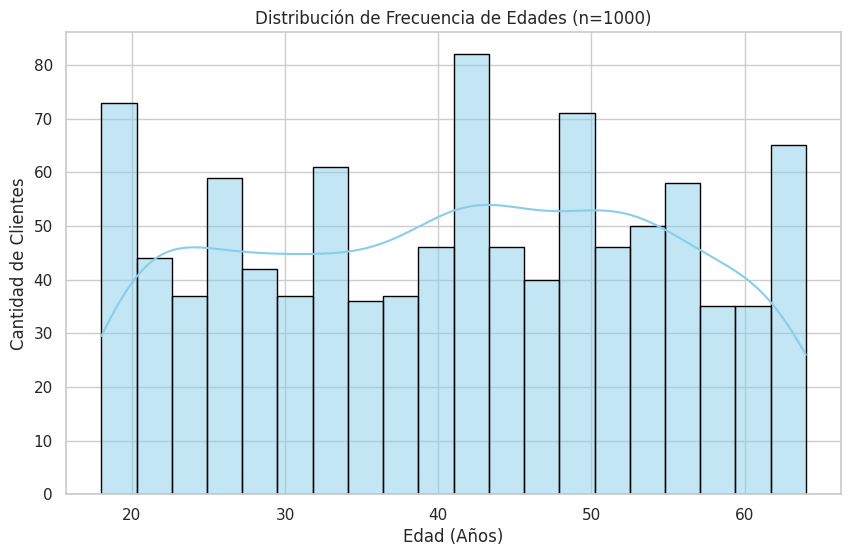

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df_banco['Edad'], bins=20, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribución de Frecuencia de Edades (n=1000)')
plt.xlabel('Edad (Años)')
plt.ylabel('Cantidad de Clientes')
plt.show()

Las barras muestran cuántos clientes hay en cada rango de edad, la línea indica que la distribución es uniforme (no hay un grupo de edad que domine masivamente sobre otros).

## Bocplot

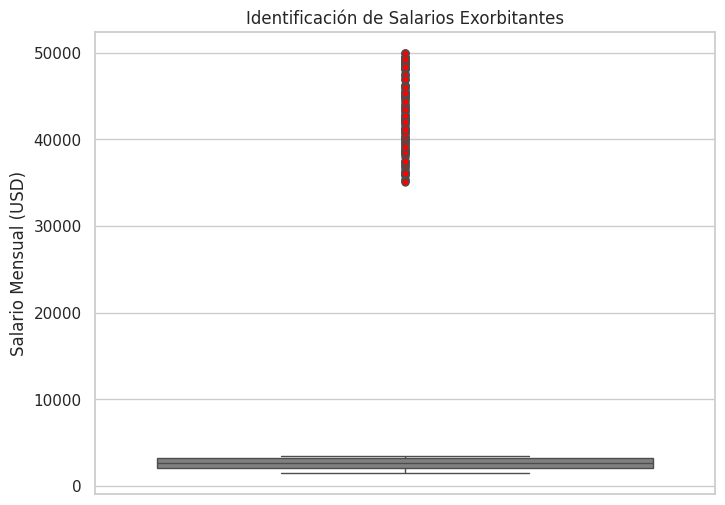

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_banco['Salario Mensual (USD)'], color='gray', flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 5})
plt.title('Identificación de Salarios Exorbitantes')
plt.ylabel('Salario Mensual (USD)')
plt.show()

La Caja gris representa la mayor parte de la población, está aplastada muy cerca de el cero, la razón de esto es  porque la mayoría de clientes tienen salarios normales (entre 1,500 y 3,500 USD).

Los puntos rojos (Outliers), son los clientes que ganaan sumas exorbitantes

La Media no sirve aquí. Si calculo el promedio, los outliers jalaran el valor hacia arriba, dando una falsa impresión de riqueza. La Mediana (la línea dentro de la caja gris) es la que realmente dice qué gana un cliente común.

# dispersión

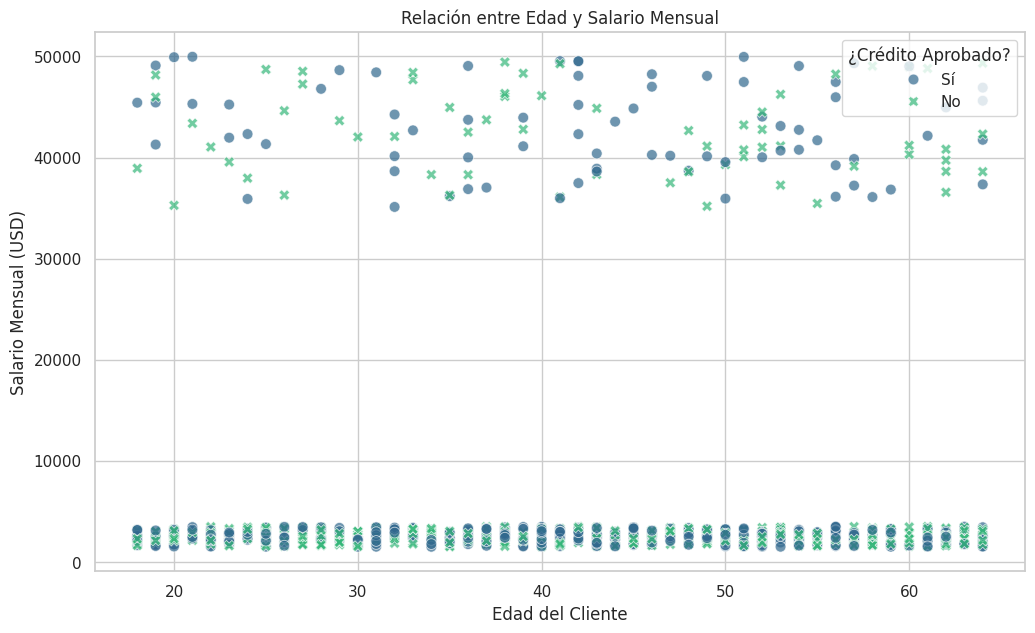

In [14]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Edad', y='Salario Mensual (USD)',
                data=df_banco,
                hue='Crédito Aprobado',
                style='Crédito Aprobado',
                palette='viridis',
                s=60, alpha=0.7)

plt.title('Relación entre Edad y Salario Mensual')
plt.xlabel('Edad del Cliente')
plt.ylabel('Salario Mensual (USD)')
plt.legend(title='¿Crédito Aprobado?', loc='upper right')
plt.show()

Al igual que en el gráfico anterior, abajo estan los clientes con ingresos tipicos y arriba están los clientes con ingresos exorbitantes, la edad no es una buena fora de medir, hay varios cilentes con sumas exorbitnaes y muy poca edad